<a href="https://colab.research.google.com/github/shaheermsa10170-max/supply-chain-by-SA-fall-2026/blob/main/data/synthetic/%20Chenab%20PO%20analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
print("Setup working:", pd.__version__)

Setup working: 2.2.3


### Load Data

First, let's load the provided Excel file into a pandas DataFrame and display the first few rows to understand its structure and column names.

In [ ]:
import pandas as pd # Ensure pandas is imported
try:
    # Loading the data explicitly from the 'Procurement_Data' sheet
    df = pd.read_excel('/content/Chenab_Motors_Procurement_Practice_Dataset.xlsx', sheet_name='Procurement_Data')
    print("Data loaded successfully from 'Procurement_Data' sheet. Displaying the first 5 rows:")
    display(df.head())
    print("\nColumn information:")
    df.info()
except FileNotFoundError:
    print("Error: The file 'Chenab_Motors_Procurement_Practice_Dataset.xlsx' was not found. Please ensure it's uploaded to the /content directory.")
except Exception as e:
    print(f"An error occurred while loading the Excel file: {e}")

Data loaded successfully from 'Procurement_Data' sheet. Displaying the first 5 rows:


,PO Number,PO Line Item,Vendor ID,Vendor,Plant,Department,Cost Center,Requisitioner,Material Group,Quantity,...,Creation Date,GR Date,GR Value (PKR),Invoice Date,Invoice Amount (PKR),Paid Amount (PKR),Outstanding Invoice (PKR),Payment Terms,Currency,PO Status
0,PO-100307,2,V-1057,Al-Noor Fabric Exports,Lahore Plant,Quality Assurance,CC-3001,I. Chaudhry,MRO & Spares,3,...,2024-05-31 00:00:00,2024-06-17,7293.0,2024-06-18,7185.0,2910,4275,Net 60,PKR,Partially Invoiced
1,PO-101660,1,V-1010,Modern Fasteners Co.,Faisalabad Plant,Production,CC-1003,H. Malik,Engine & Powertrain Components,11,...,2024-07-23 00:00:00,2024-07-30,256257.0,2024-08-09,256526.0,63790,192736,Net 45,PKR,Partially Invoiced
2,PO-107059,1,V-1055,Wazir Ali Enterprises,Faisalabad Plant,IT,CC-5001,I. Chaudhry,Interior Components,3,...,2025-05-11 00:00:00,2025-05-16,9539.0,2025-05-23,9586.0,9586,0,Net 30,PKR,Closed
3,PO-102998,1,V-1027,Eco Weave Pakistan,Karachi Plant,Maintenance,CC-2001,N. Sheikh,Body Panels & Sheet Metal,7,...,2024-10-09 00:00:00,2024-10-23,115883.0,2024-10-27,116924.0,116924,0,Net 45,PKR,Closed
4,PO-106461,1,V-1032,Al-Rehan Fabric Mills,Lahore Plant,Administration,CC-6002,Z. Latif,Office Supplies & Stationery,1,...,2025-03-03 00:00:00,2025-03-07,523.0,2025-03-15,517.0,517,0,Net 30,PKR,Closed



Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10050 entries, 0 to 10049
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   PO Number                  10050 non-null  object        
 1   PO Line Item               10050 non-null  int64         
 2   Vendor ID                  10050 non-null  object        
 3   Vendor                     9930 non-null   object        
 4   Plant                      10050 non-null  object        
 5   Department                 10050 non-null  object        
 6   Cost Center                9929 non-null   object        
 7   Requisitioner              10050 non-null  object        
 8   Material Group             9927 non-null   object        
 9   Quantity                   10050 non-null  int64         
 10  Unit Price (PKR)           10050 non-null  int64         
 11  PO Value (PKR)             10050 non-null  flo

In [ ]:
xls = pd.ExcelFile('/content/Chenab_Motors_Procurement_Practice_Dataset.xlsx')
print("Sheets found in the Excel file:", xls.sheet_names)

Sheets found in the Excel file: ['README', 'Procurement_Data']


### Finding Top 3 Suppliers

To identify the top 3 suppliers, we'll assume you have a DataFrame named `df` with columns such as `supplier_name` (for supplier identification) and `total_spend` (or a similar quantitative metric like `quantity_supplied`, `order_value`, etc., to rank them).

If your column names are different, please adjust the code accordingly.

In [ ]:
try:
    # Assuming 'df' is your DataFrame, 'supplier_name' is the supplier identifier, and 'total_spend' is the metric for ranking.
    # You might need to replace 'total_spend' with 'quantity_supplied', 'order_value', etc., based on your dataset.
    supplier_performance = df.groupby('supplier_name')['total_spend'].sum().reset_index()

    # Sort by the metric in descending order and get the top 3
    top_3_suppliers = supplier_performance.sort_values(by='total_spend', ascending=False).head(3)

    print("Top 3 Suppliers (by Total Spend):")
    display(top_3_suppliers)

except KeyError as e:
    print(f"Error: Column not found. Please check if 'supplier_name' and 'total_spend' (or your chosen metric) exist in your DataFrame.\nDetails: {e}")
except NameError:
    print("Error: DataFrame 'df' not found. Please ensure your data is loaded into a DataFrame named 'df'.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

It looks like the dataset contains columns such as `Supplier Name` and `Order Value` which are suitable for identifying suppliers and their spend. I will modify the existing code to use these column names to find the top 3 suppliers.

In [ ]:
import pandas as pd
df = pd.read_excel("/content/Chenab_Motors_Procurement_Practice_Dataset.xlsx", sheet_name="Procurement_Data")
print(df.shape)
print(df.head())

(10050, 22)
   PO Number  PO Line Item Vendor ID                  Vendor  \
0  PO-100307             2    V-1057  Al-Noor Fabric Exports   
1  PO-101660             1    V-1010    Modern Fasteners Co.   
2  PO-107059             1    V-1055   Wazir Ali Enterprises   
3  PO-102998             1    V-1027      Eco Weave Pakistan   
4  PO-106461             1    V-1032   Al-Rehan Fabric Mills   

              Plant         Department Cost Center Requisitioner  \
0      Lahore Plant  Quality Assurance     CC-3001   I. Chaudhry   
1  Faisalabad Plant         Production     CC-1003      H. Malik   
2  Faisalabad Plant                 IT     CC-5001   I. Chaudhry   
3     Karachi Plant        Maintenance     CC-2001     N. Sheikh   
4      Lahore Plant     Administration     CC-6002      Z. Latif   

                   Material Group  Quantity  ...        Creation Date  \
0                    MRO & Spares         3  ...  2024-05-31 00:00:00   
1  Engine & Powertrain Components        11  ...

In [ ]:
import pandas as pd

# Assuming 'df' is your DataFrame. Using 'Vendor' for supplier identification and 'PO Value (PKR)' for the metric.
supplier_performance = df.groupby('Vendor')['PO Value (PKR)'].sum().reset_index()

# Sort by the metric in descending order and get the top 3
top_3_suppliers = supplier_performance.sort_values(by='PO Value (PKR)', ascending=False).head(3)

print("Top 3 Suppliers (by Total PO Value):")
display(top_3_suppliers)

Top 3 Suppliers (by Total PO Value):


,Vendor,PO Value (PKR)
0,Al-Amin Auto Components,1.018835e+08
27,Karachi Steel Traders,5.007253e+07
59,Zaman Brothers Trading,3.586614e+07


### Key Procurement Metrics

Now, let's calculate some key procurement metrics as requested, including total PO spend, total number of POs, total number of vendors, average PO value, and average line-item value.

In [ ]:
# 1. Calculate Total PO Spend (Total PO Value)
total_po_spend = df['PO Value (PKR)'].sum()
print(f"Total PO Spend: {total_po_spend:,.2f} PKR")

Total PO Spend: 614,670,044.11 PKR


In [ ]:
# 2. Calculate Total Number of POs (Unique PO Numbers)
total_pos = df['PO Number'].nunique()
print(f"Total Number of Purchase Orders (POs): {total_pos}")

Total Number of Purchase Orders (POs): 7406


In [ ]:
# 3. Calculate Total Number of Vendors (Unique Vendor IDs/Names)
total_vendors = df['Vendor'].nunique()
print(f"Total Number of Unique Vendors: {total_vendors}")

Total Number of Unique Vendors: 60


In [ ]:
# 4. Calculate Average PO Value
average_po_value = df['PO Value (PKR)'].mean()
print(f"Average PO Value: {average_po_value:,.2f} PKR")

Average PO Value: 61,161.20 PKR


In [ ]:
# 5. Calculate Average Line-Item Value (Average Unit Price)
average_line_item_value = df['Unit Price (PKR)'].mean()
print(f"Average Line-Item Value (Unit Price): {average_line_item_value:,.2f} PKR")

Average Line-Item Value (Unit Price): 6,391.67 PKR


### Top 10 Vendors by Total PO Value

Let's identify the top 10 vendors based on their total Purchase Order (PO) value and visualize this data.

In [ ]:
# Calculate total PO Value for each vendor
vendor_po_value = df.groupby('Vendor')['PO Value (PKR)'].sum().reset_index()

# Sort in descending order and get the top 10
top_10_vendors = vendor_po_value.sort_values(by='PO Value (PKR)', ascending=False).head(10)

print("Top 10 Vendors by Total PO Value:")
display(top_10_vendors)

Top 10 Vendors by Total PO Value:


,Vendor,PO Value (PKR)
0,Al-Amin Auto Components,1.018835e+08
27,Karachi Steel Traders,5.007253e+07
59,Zaman Brothers Trading,3.586614e+07
5,Anwar Electric Works,3.146678e+07
54,TCS Cargo Services,2.703754e+07
21,Gulistan Logistics,1.972002e+07
51,Speedline Logistics,1.750654e+07
49,Sindh Spinners Co.,1.655498e+07
56,United Rubber Industries,1.587658e+07
31,Modern Fasteners Co.,1.338250e+07


/tmp/ipykernel_5672/1413310647.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PO Value (PKR)', y='Vendor', data=top_10_vendors, palette='viridis')


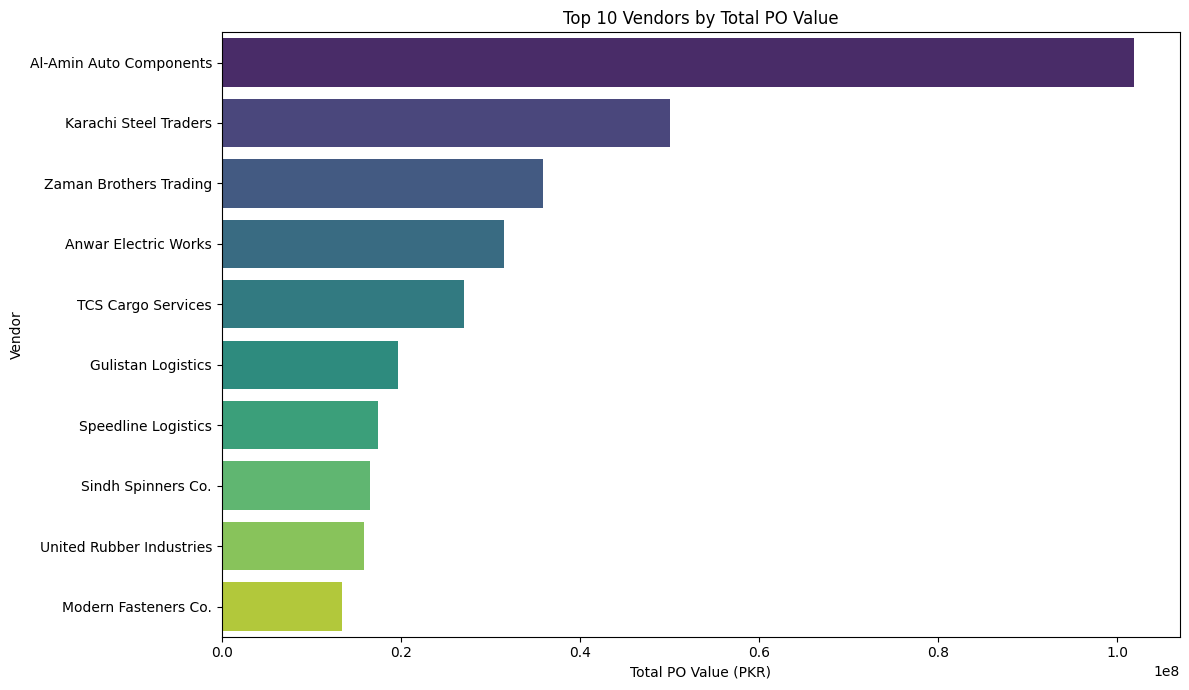

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='PO Value (PKR)', y='Vendor', data=top_10_vendors, palette='viridis')
plt.title('Top 10 Vendors by Total PO Value')
plt.xlabel('Total PO Value (PKR)')
plt.ylabel('Vendor')
plt.tight_layout()
plt.show()

### Pareto Analysis (80/20 Rule) of Vendors by PO Value

Let's apply the Pareto principle to identify which vendors account for approximately 80% of the total Purchase Order (PO) spend.

In [ ]:
# 1. Calculate total PO Value for each vendor
vendor_spend = df.groupby('Vendor')['PO Value (PKR)'].sum().reset_index()

# 2. Sort vendors by total PO Value in descending order
vendor_spend = vendor_spend.sort_values(by='PO Value (PKR)', ascending=False).reset_index(drop=True)

# 3. Calculate cumulative sum and cumulative percentage of PO Value
vendor_spend['Cumulative PO Value (PKR)'] = vendor_spend['PO Value (PKR)'].cumsum()
vendor_spend['Cumulative Percentage'] = (vendor_spend['Cumulative PO Value (PKR)'] / vendor_spend['PO Value (PKR)'].sum()) * 100

# 4. Identify vendors contributing to approximately 80% of total spend
pareto_vendors = vendor_spend[vendor_spend['Cumulative Percentage'] <= 80]
num_pareto_vendors = len(pareto_vendors)

print("Pareto Analysis of Vendors by PO Value (Cumulative Spend):")
display(vendor_spend)

print(f"\nNumber of vendors contributing to ~80% of total spend: {num_pareto_vendors}")
print("These vendors are:")
display(pareto_vendors)

Pareto Analysis of Vendors by PO Value (Cumulative Spend):


,Vendor,PO Value (PKR),Cumulative PO Value (PKR),Cumulative Percentage
0,Al-Amin Auto Components,1.018835e+08,1.018835e+08,16.750597
1,Karachi Steel Traders,5.007253e+07,1.519560e+08,24.982986
2,Zaman Brothers Trading,3.586614e+07,1.878222e+08,30.879713
3,Anwar Electric Works,3.146678e+07,2.192890e+08,36.053145
4,TCS Cargo Services,2.703754e+07,2.463265e+08,40.498369
5,Gulistan Logistics,1.972002e+07,2.660465e+08,43.740523
6,Speedline Logistics,1.750654e+07,2.835531e+08,46.618762
7,Sindh Spinners Co.,1.655498e+07,3.001080e+08,49.340554
8,United Rubber Industries,1.587658e+07,3.159846e+08,51.950812
9,Modern Fasteners Co.,1.338250e+07,3.293671e+08,54.151020



Number of vendors contributing to ~80% of total spend: 27
These vendors are:


,Vendor,PO Value (PKR),Cumulative PO Value (PKR),Cumulative Percentage
0,Al-Amin Auto Components,1.018835e+08,1.018835e+08,16.750597
1,Karachi Steel Traders,5.007253e+07,1.519560e+08,24.982986
2,Zaman Brothers Trading,3.586614e+07,1.878222e+08,30.879713
3,Anwar Electric Works,3.146678e+07,2.192890e+08,36.053145
4,TCS Cargo Services,2.703754e+07,2.463265e+08,40.498369
5,Gulistan Logistics,1.972002e+07,2.660465e+08,43.740523
6,Speedline Logistics,1.750654e+07,2.835531e+08,46.618762
7,Sindh Spinners Co.,1.655498e+07,3.001080e+08,49.340554
8,United Rubber Industries,1.587658e+07,3.159846e+08,51.950812
9,Modern Fasteners Co.,1.338250e+07,3.293671e+08,54.151020


/tmp/ipykernel_5672/1094253028.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vendor_spend.index, y='PO Value (PKR)', data=vendor_spend, palette='Blues_d', ax=ax1)


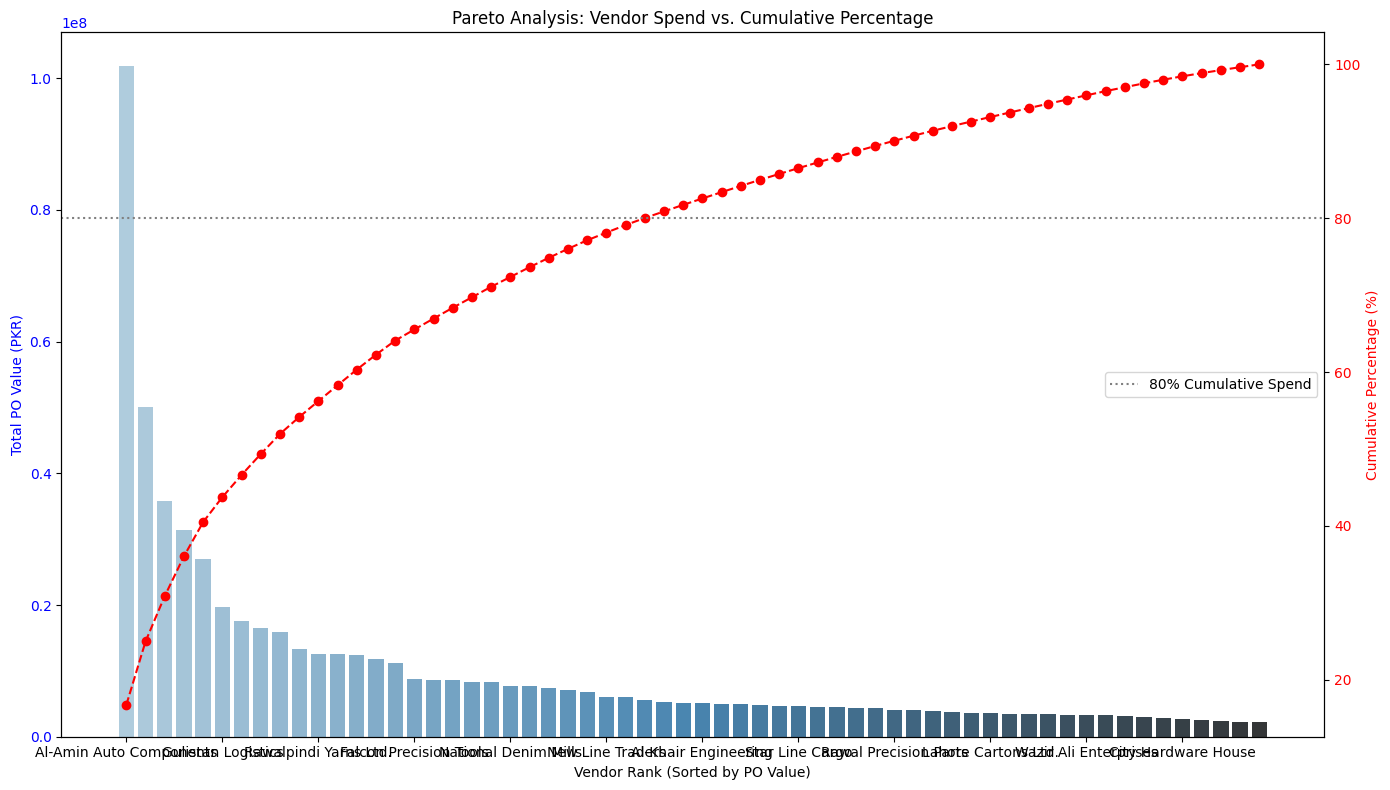

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
fig, ax1 = plt.subplots(figsize=(14, 8))

# Plot individual vendor spend as a bar chart on the primary y-axis (ax1)
sns.barplot(x=vendor_spend.index, y='PO Value (PKR)', data=vendor_spend, palette='Blues_d', ax=ax1)
ax1.set_xlabel('Vendor Rank (Sorted by PO Value)')
ax1.set_ylabel('Total PO Value (PKR)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a secondary y-axis for the cumulative percentage (ax2)
ax2 = ax1.twinx()
ax2.plot(vendor_spend.index, vendor_spend['Cumulative Percentage'], color='red', marker='o', linestyle='--')
ax2.set_ylabel('Cumulative Percentage (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add a horizontal line at 80% for Pareto visualization
ax2.axhline(y=80, color='gray', linestyle=':', label='80% Cumulative Spend')
ax2.legend(loc='center right')

# Set title and adjust layout
plt.title('Pareto Analysis: Vendor Spend vs. Cumulative Percentage')
plt.xticks(ticks=vendor_spend.index[::5], labels=vendor_spend['Vendor'][::5], rotation=90)
plt.tight_layout()
plt.show()

This code snippet groups your data by `supplier_name`, calculates the sum of `total_spend` for each supplier, and then sorts them to show the top 3. Remember to replace `supplier_name` and `total_spend` with the actual column names from your dataset if they are different.

### Synthetic Weekly Demand Data for 'Grade Black Interior'

To calibrate the scale, I will assume an illustrative annual revenue of **PKR 250 billion** for Indus Motor Company. For a specific product like 'Grade Black Interior', I've estimated it contributes about **0.01%** of the total revenue annually, leading to **PKR 25 million** in annual sales for this product. With an assumed average unit price of **PKR 25,000**, this translates to approximately **1,000 units** sold annually, or a baseline of about **19 units per week**.


In [1]:
import pandas as pd
import numpy as np

# --- Parameters ---
num_weeks = 104  # 2 years
start_date = '2023-01-01'

baseline_units = 19  # Calibrated as per reasoning above
unit_price_start = 25000  # PKR

# Trend: slight linear growth (e.g., 0.1% per week)
weekly_growth_rate = 0.001

# Seasonality (example: peaks around Eid, slight dip in monsoon)
# Approximate Eid weeks (these would need to be dynamic or based on historical data for real accuracy)
# For this synthetic data, let's pick some illustrative weeks.
seasonal_peaks_weeks = [15, 40, 67, 92] # Example: representing two Eid periods per year
seasonal_peak_effect = 0.20 # 20% increase

monsoon_weeks = list(range(26, 35)) + list(range(78, 87)) # Example: July-August
monsoon_effect = -0.05 # 5% decrease

# Promotions
num_promotions = 15 # Approximately 15 weeks out of 104
promotion_lift_min = 0.10 # 10% lift
promotion_lift_max = 0.40 # 40% lift
promotion_weeks = np.random.choice(num_weeks, num_promotions, replace=False)

# Price variation (inflation and promotion discounts)
inflation_rate_weekly = 0.0005 # 0.05% weekly inflation
promotion_price_discount_min = 0.05 # 5% discount
promotion_price_discount_max = 0.10 # 10% discount

# Noise
noise_std_dev_factor = 0.10 # 10% of current demand

# --- Generate Data ---
dates = pd.date_range(start=start_date, periods=num_weeks, freq='W-MON')

df_demand = pd.DataFrame({
    'Week_Start_Date': dates,
    'Units_Sold': np.zeros(num_weeks),
    'Unit_Price_PKR': np.zeros(num_weeks),
    'Promotion_Flag': np.zeros(num_weeks, dtype=int),
    'Notes': [''] * num_weeks
})

current_units = baseline_units
current_price = unit_price_start

for i in range(num_weeks):
    # Apply trend
    trend_effect = current_units * weekly_growth_rate
    current_units += trend_effect

    # Apply seasonality
    if i in seasonal_peaks_weeks:
        current_units *= (1 + seasonal_peak_effect)
        df_demand.loc[i, 'Notes'] += 'Eid week / Seasonal Peak. '
    elif i in monsoon_weeks:
        current_units *= (1 + monsoon_effect)
        df_demand.loc[i, 'Notes'] += 'Monsoon Season. '

    # Apply promotions
    if i in promotion_weeks:
        promotion_lift = np.random.uniform(promotion_lift_min, promotion_lift_max)
        current_units *= (1 + promotion_lift)
        df_demand.loc[i, 'Promotion_Flag'] = 1
        df_demand.loc[i, 'Notes'] += 'Promotional Offer. '

        # Apply price discount for promotions
        discount = np.random.uniform(promotion_price_discount_min, promotion_price_discount_max)
        df_demand.loc[i, 'Unit_Price_PKR'] = current_price * (1 - discount)
    else:
        df_demand.loc[i, 'Unit_Price_PKR'] = current_price

    # Apply noise
    noise = np.random.normal(0, current_units * noise_std_dev_factor)
    current_units += noise

    # Ensure Units_Sold doesn't go below zero
    df_demand.loc[i, 'Units_Sold'] = max(0, round(current_units))

    # Update price for inflation
    current_price *= (1 + inflation_rate_weekly)

# Clean up notes
df_demand['Notes'] = df_demand['Notes'].str.strip()

# Display the generated DataFrame
print("Generated Synthetic Weekly Demand Dataset:")
display(df_demand.head())


Generated Synthetic Weekly Demand Dataset:


,Week_Start_Date,Units_Sold,Unit_Price_PKR,Promotion_Flag,Notes
0,2023-01-02,18.0,25000.000000,0,
1,2023-01-09,20.0,25012.500000,0,
2,2023-01-16,20.0,25025.006250,0,
3,2023-01-23,20.0,25037.518753,0,
4,2023-01-30,22.0,23767.680012,1,Promotional Offer.


### Assumptions

*   **Starting Weekly Demand**: A baseline of approximately 19 units per week was assumed. This was derived from an illustrative annual revenue of PKR 250 billion for Indus Motor Company, with the 'Grade Black Interior' product estimated to contribute 0.01% (PKR 25 million) of that, and an average unit price of PKR 25,000.
*   **Trend**: A slight linear growth of 0.1% per week was incorporated, reflecting a generally stable or moderately expanding market for vehicle accessories or specific interior upgrades within the automotive sector.
*   **Seasonal Pattern**: Seasonal peaks were introduced around traditional festival periods (like Eid in Pakistan), simulating increased consumer spending, while a slight dip was modeled during the monsoon season (July-August) due to potential disruptions or decreased outdoor activity.
*   **Limitations**: This dataset is synthetic and does not capture unpredictable external factors such as sudden economic downturns, major supply chain disruptions, significant policy changes, introduction of competing products, or the launch of entirely new car models by the company. It also simplifies pricing dynamics and assumes the 'Grade Black Interior' is treated as a distinct product with its own demand drivers.